Running sweep for 60 delta values...


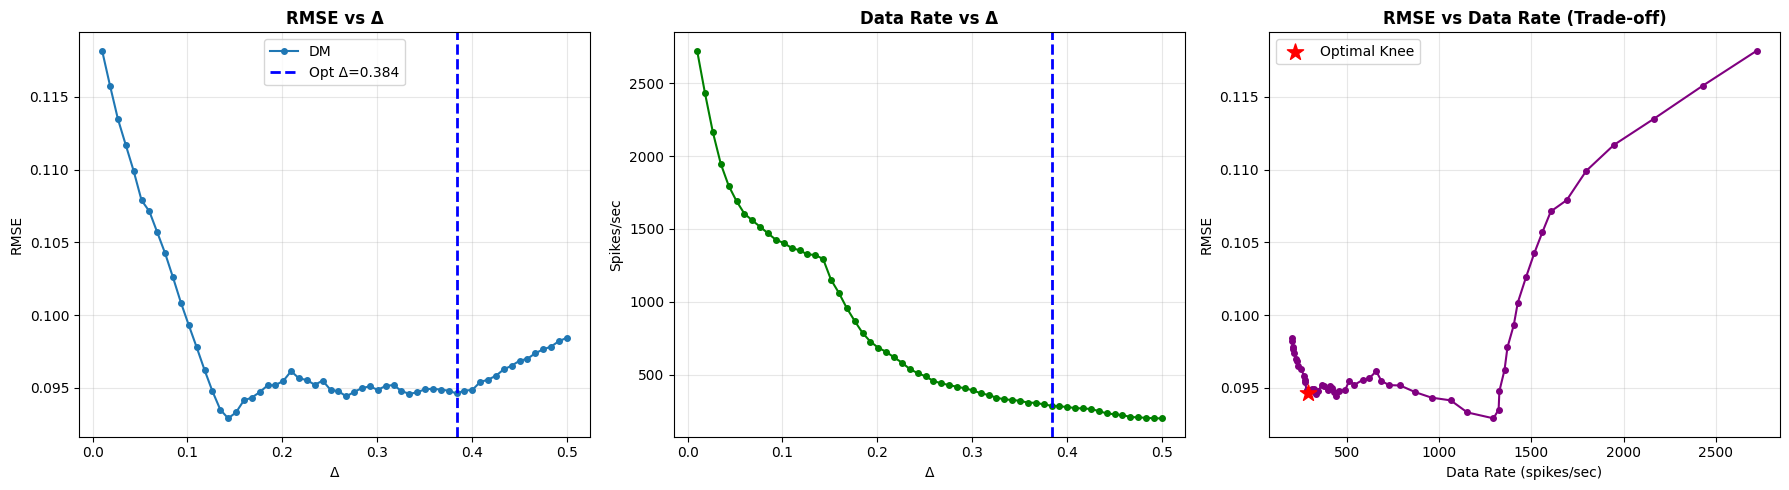

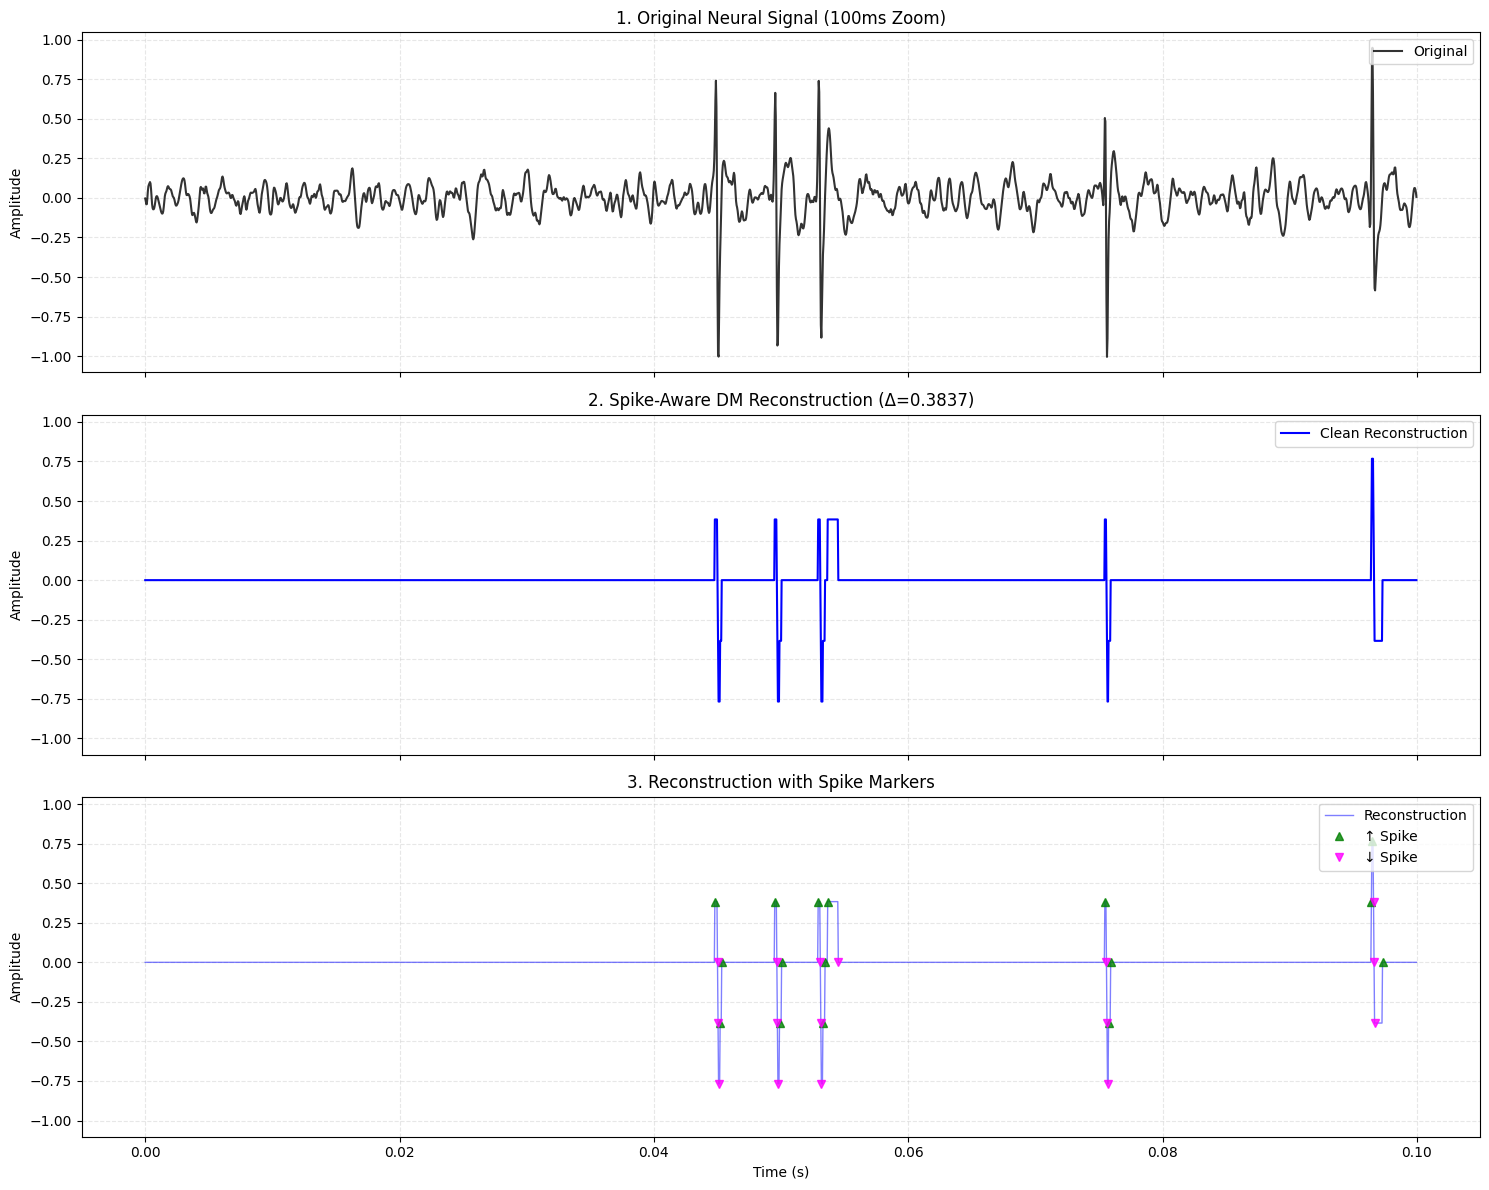


FINAL RESULTS - Spike-Aware Delta Modulation
Optimal Delta (Δ):     0.3837
RMSE:                  0.0946
Data Rate:             288.00 spikes/sec
Total Spikes:          288
Signal Duration:       1.000 seconds
Noise Floor Est:       0.1423


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy.io import loadmat
from kneed import KneeLocator

# ==========================================
# 1. Data Import & Pre-processing
# ==========================================
try:
    MAT = loadmat('./C_Difficult1_noise01.mat')  # <-- your dataset
    rawData = np.array(MAT['data'])[0]
    sampling_interval = np.array(MAT['samplingInterval'][0][0]) * 1e-3
    sample_rate = int(1 / sampling_interval)
    data = rawData[:int(sample_rate)] # Use 1 second
except FileNotFoundError:
    print("Warning: .mat file not found. Generating synthetic data.")
    sample_rate = 24000
    t = np.linspace(0, 1, sample_rate)
    data = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)

# Band-pass filter
b, a = butter(4, [300 * 2 / sample_rate, 5000 * 2 / sample_rate], btype='band')
data = lfilter(b, a, data)

# ==========================================
# 2. Helper Functions
# ==========================================

def compute_rmse(x, y):
    return np.sqrt(np.mean((x - y) ** 2))

def compute_data_rate(spikes, duration):
    return len(spikes) / duration  # spikes/sec

def estimate_noise_floor(x, factor=2.5):
    mad = np.median(np.abs(x - np.median(x)))
    return factor * mad

def spike_aware_dm(x, delta, noise_floor=0.04, hold_time=3):
    """Delta Modulation that ignores small noise."""
    y = np.zeros_like(x)
    spikes = []
    hold = 0
    # Assume starting value matches first sample or 0
    y[0] = 0 
    
    for n in range(1, len(x)):
        diff = x[n] - y[n-1]
        
        # If noise is small and we aren't in a hold period (optional logic check)
        # Note: Your original logic had hold-- inside the noise check.
        # This implementation follows your provided logic exactly.
        if abs(diff) < noise_floor:
            if hold > 0:
                hold -= 1
            y[n] = y[n-1]
            continue
            
        if diff > delta:
            y[n] = y[n-1] + delta
            spikes.append((n, 1))
            hold = hold_time
        elif diff < -delta:
            y[n] = y[n-1] - delta
            spikes.append((n, -1))
            hold = hold_time
        else:
            # Fallback if diff is between noise_floor and delta? 
            # In standard DM, this usually implies no change or following the previous.
            # Based on your snippet, we just hold value.
            y[n] = y[n-1]
            
    return y, spikes

def plot_spike_markers(ax, spikes, y_rec, time_axis, marker_size=5):
    """Plots spikes on the reconstructed signal axis."""
    if not spikes: return
    idx_up = [n for n, s in spikes if s > 0]
    idx_dn = [n for n, s in spikes if s < 0]
    if idx_up:
        ax.plot(time_axis[idx_up], y_rec[idx_up], '^', color='green', markersize=marker_size, label="↑ Spike", alpha=0.8)
    if idx_dn:
        ax.plot(time_axis[idx_dn], y_rec[idx_dn], 'v', color='magenta', markersize=marker_size, label="↓ Spike", alpha=0.8)

# ==========================================
# 3. Sweep & Knee Finding
# ==========================================
deltas = np.linspace(0.01, 0.5, 60)
duration = len(data) / sample_rate
noise_thr = estimate_noise_floor(data)
results_dm = []

print(f"Running sweep for {len(deltas)} delta values...")
for d in deltas:
    y_dm, spikes_dm = spike_aware_dm(data, d, noise_floor=noise_thr)
    rmse_dm = compute_rmse(data, y_dm)
    dr_dm = compute_data_rate(spikes_dm, duration)
    results_dm.append((d, rmse_dm, dr_dm))

results_df = pd.DataFrame(results_dm, columns=["delta", "RMSE", "DataRate"])
results_sorted = results_df.sort_values("DataRate").reset_index(drop=True)

# Knee Logic
knee_dm = KneeLocator(
    results_sorted["DataRate"], results_sorted["RMSE"],
    curve="convex", direction="decreasing"
)
opt_drate_knee = knee_dm.knee

if opt_drate_knee is None:
    opt_row = results_df.loc[results_df["RMSE"].idxmin()]
else:
    idx = (results_df["DataRate"] - opt_drate_knee).abs().idxmin()
    opt_row = results_df.loc[idx]

opt_delta = opt_row["delta"]
opt_rmse  = opt_row["RMSE"]
opt_drate = opt_row["DataRate"]

# Final Reconstruction
y_opt, spikes_opt = spike_aware_dm(data, opt_delta, noise_floor=noise_thr)
time_axis = np.arange(len(data)) / sample_rate

# ==========================================
# 4. Visualization
# ==========================================

# --- A. Metric Analysis (Knee Graphs) ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RMSE vs Delta
axs[0].plot(results_df["delta"], results_df["RMSE"], 'o-', label="DM", markersize=4)
axs[0].axvline(opt_delta, color='blue', linestyle='--', linewidth=2, label=f"Opt Δ={opt_delta:.3f}")
axs[0].set_title("RMSE vs Δ", fontsize=12, fontweight='bold')
axs[0].set_xlabel("Δ")
axs[0].set_ylabel("RMSE")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Data Rate vs Delta
axs[1].plot(results_df["delta"], results_df["DataRate"], 'o-', color='green', markersize=4)
axs[1].axvline(opt_delta, color='blue', linestyle='--', linewidth=2)
axs[1].set_title("Data Rate vs Δ", fontsize=12, fontweight='bold')
axs[1].set_xlabel("Δ")
axs[1].set_ylabel("Spikes/sec")
axs[1].grid(True, alpha=0.3)

# Plot 3: Knee Curve
axs[2].plot(results_df["DataRate"], results_df["RMSE"], 'o-', color='purple', markersize=4)
axs[2].scatter(opt_drate, opt_rmse, color='red', s=150, zorder=5, marker='*', label="Optimal Knee")
axs[2].set_title("RMSE vs Data Rate (Trade-off)", fontsize=12, fontweight='bold')
axs[2].set_xlabel("Data Rate (spikes/sec)")
axs[2].set_ylabel("RMSE")
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- B. 3-Panel Stacked Zoom (100ms) ---
lim_zoom = int(0.1 * sample_rate)
spikes_zoom = [(n, s) for n, s in spikes_opt if n < lim_zoom]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, sharey=True)

# 1. Original
ax1.plot(time_axis[:lim_zoom], data[:lim_zoom], color='black', alpha=0.8, label="Original")
ax1.set_title("1. Original Neural Signal (100ms Zoom)")
ax1.set_ylabel("Amplitude")
ax1.legend(loc="upper right")
ax1.grid(True, linestyle='--', alpha=0.3)

# 2. Clean Reconstruction
ax2.plot(time_axis[:lim_zoom], y_opt[:lim_zoom], color='blue', linewidth=1.5, label="Clean Reconstruction")
ax2.set_title(f"2. Spike-Aware DM Reconstruction (Δ={opt_delta:.4f})")
ax2.set_ylabel("Amplitude")
ax2.legend(loc="upper right")
ax2.grid(True, linestyle='--', alpha=0.3)

# 3. Reconstruction + Markers
ax3.plot(time_axis[:lim_zoom], y_opt[:lim_zoom], color='blue', linewidth=1.0, alpha=0.5, label="Reconstruction")
plot_spike_markers(ax3, spikes_zoom, y_opt, time_axis, marker_size=6)
ax3.set_title("3. Reconstruction with Spike Markers")
ax3.set_ylabel("Amplitude")
ax3.set_xlabel("Time (s)")
ax3.legend(loc="upper right")
ax3.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 5. Summary
# ==========================================
print("\n" + "="*60)
print("FINAL RESULTS - Spike-Aware Delta Modulation")
print("="*60)
print(f"Optimal Delta (Δ):     {opt_delta:.4f}")
print(f"RMSE:                  {opt_rmse:.4f}")
print(f"Data Rate:             {opt_drate:.2f} spikes/sec")
print(f"Total Spikes:          {len(spikes_opt)}")
print(f"Signal Duration:       {duration:.3f} seconds")
print(f"Noise Floor Est:       {noise_thr:.4f}")
print("="*60)


Loaded 24000 samples (1.000 s)
Running sweep for 60 delta values...
Sweep complete.
Optimal Δ (DM): 0.3837 | RMSE=0.0946 | Rate=288.00 spikes/s


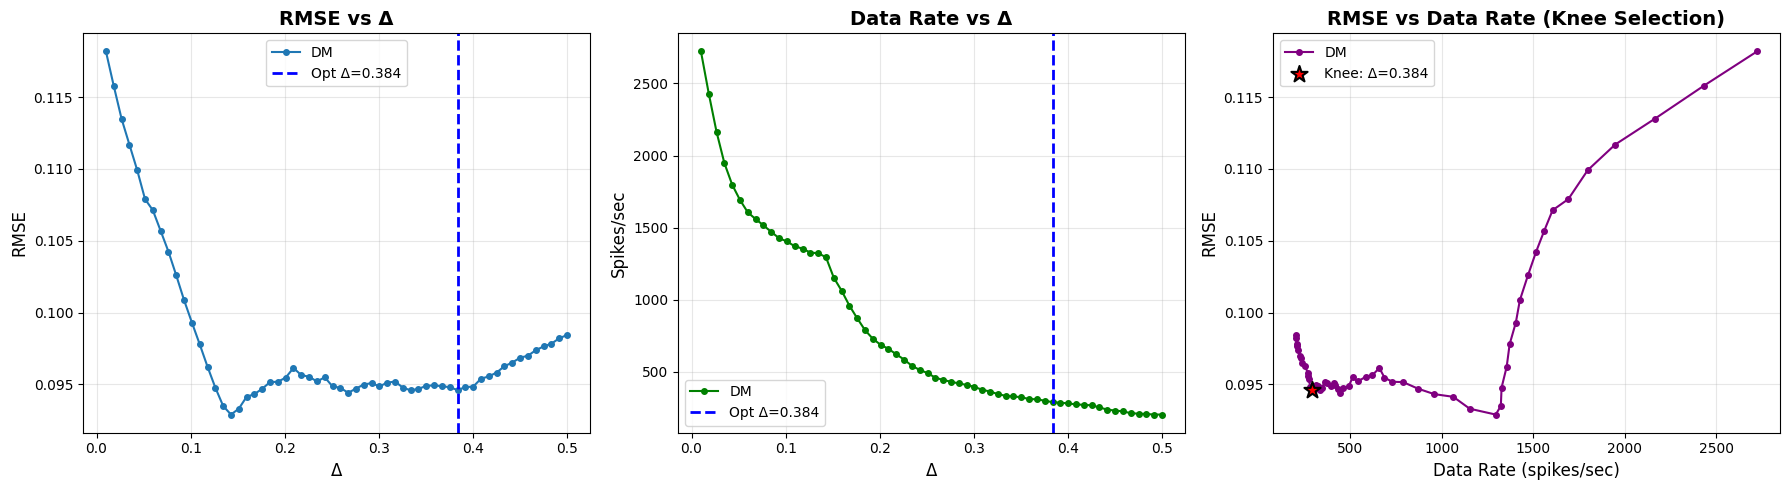

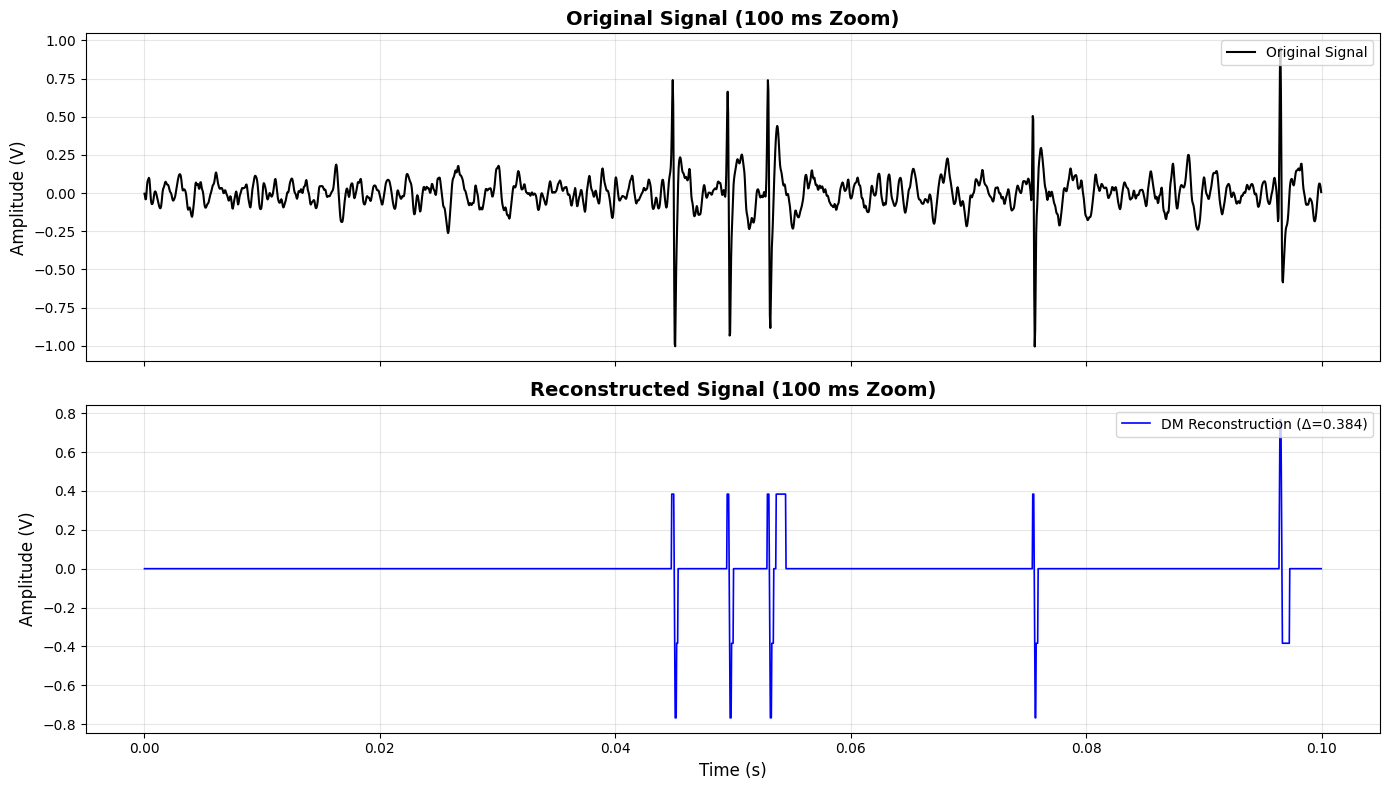

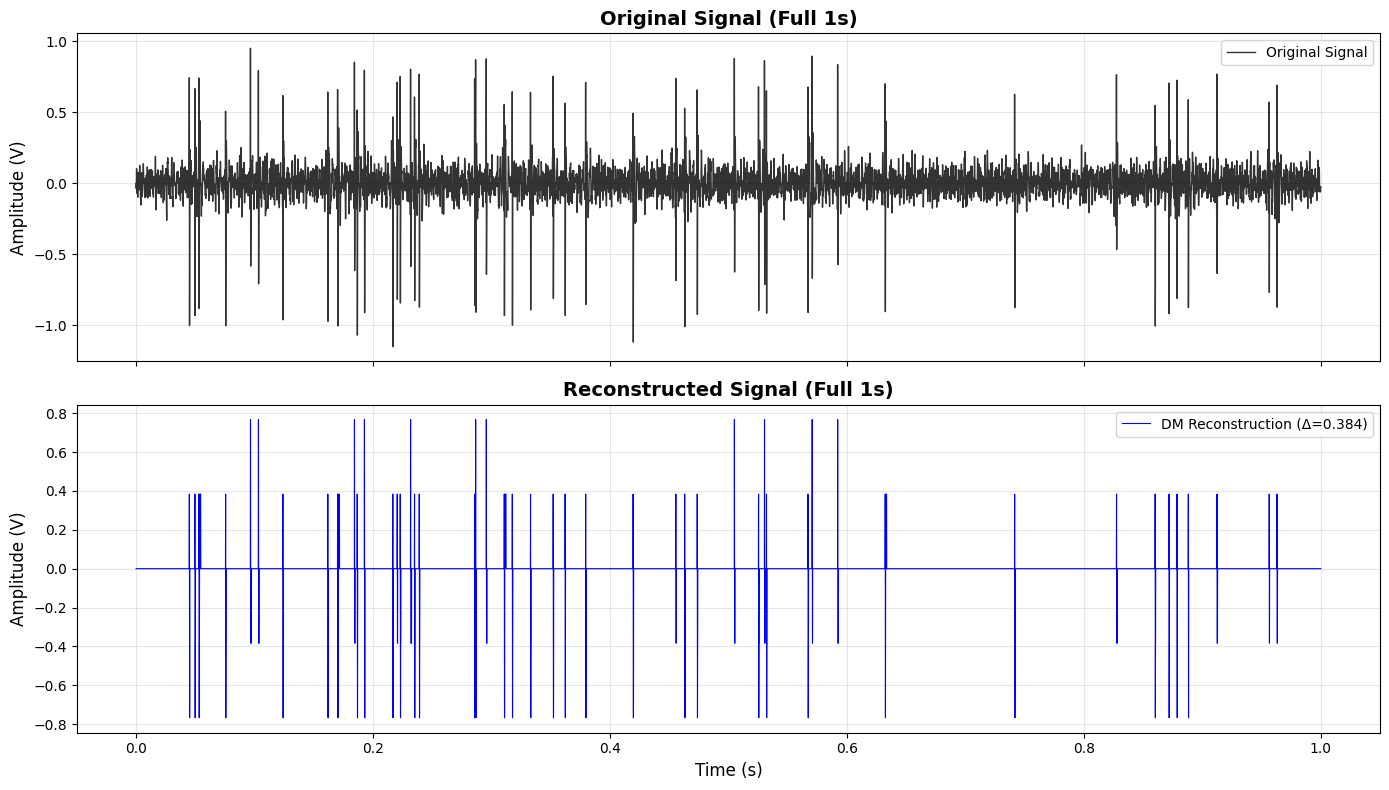


FINAL RESULTS - Spike-Aware Delta Modulation
Optimal Delta (Δ):     0.3837
RMSE:                  0.0946
Data Rate:             288.00 spikes/sec
Total Spikes:          288
Signal Duration:       1.000 seconds
Noise Floor:           0.1423


In [6]:
# Neuromorphic BMI – Spike-Aware DM & ADM
# Refined code with separated Original and Reconstructed plots

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy.io import loadmat
from kneed import KneeLocator

# ============================================================================
# Load and Preprocess Data
# ============================================================================

try:
    MAT = loadmat('./C_Difficult1_noise01.mat')  # <-- your dataset
    rawData = np.array(MAT['data'])[0]
    spikeTimeGT = np.array(MAT['spike_times'])[0][0][0]
    sampling_interval = np.array(MAT['samplingInterval'][0][0]) * 1e-3
    sample_rate = int(1 / sampling_interval)
    
    # Use 1 second of data (or more if desired)
    data = rawData[:int(sample_rate)]
    print(f"Loaded {len(data)} samples ({len(data)/sample_rate:.3f} s)")

    # Band-pass filter
    b, a = butter(4, [300 * 2 / sample_rate, 5000 * 2 / sample_rate], btype='band')
    data = lfilter(b, a, data)
    
except FileNotFoundError:
    print("Error: Dataset file './C_Difficult1_noise01.mat' not found.")
    print("Generating synthetic data for demonstration...")
    sample_rate = 25000
    t = np.linspace(0, 1, sample_rate)
    # Synthetic neural signal: spikes + noise
    data = 0.1 * np.random.randn(sample_rate)
    # Add some random spikes
    spike_locs = np.random.choice(sample_rate, 50, replace=False)
    for loc in spike_locs:
        data[loc:loc+10] += np.hanning(10) * 2.0  # Simple spike shape
    
    # Filter synthetic data to match typical processing
    b, a = butter(4, [300 * 2 / sample_rate, 5000 * 2 / sample_rate], btype='band')
    data = lfilter(b, a, data)

# ============================================================================
# Helper Functions
# ============================================================================

def compute_rmse(x, y):
    return np.sqrt(np.mean((x - y) ** 2))

def compute_data_rate(spikes, duration):
    return len(spikes) / duration  # spikes/sec

def estimate_noise_floor(x, factor=2.5):
    mad = np.median(np.abs(x - np.median(x)))
    return factor * mad

# ============================================================================
# Spike-Aware DM 
# ============================================================================

def spike_aware_dm(x, delta, noise_floor=0.05, hold_time=3):
    """Delta Modulation that ignores small noise."""
    y = np.zeros_like(x)
    spikes = []
    hold = 0
    for n in range(1, len(x)):
        diff = x[n] - y[n-1]
        if abs(diff) < noise_floor:
            if hold > 0:
                hold -= 1
            y[n] = y[n-1]
            continue
        if diff > delta:
            y[n] = y[n-1] + delta
            spikes.append((n, 1))
            hold = hold_time
        elif diff < -delta:
            y[n] = y[n-1] - delta
            spikes.append((n, -1))
            hold = hold_time
        else:
            y[n] = y[n-1]
    return y, spikes

# ============================================================================
# Delta Sweep (RMSE + DataRate)
# ============================================================================

deltas = np.linspace(0.01, 0.5, 60)
duration = len(data) / sample_rate
noise_thr = estimate_noise_floor(data)
results_dm = []

print(f"Running sweep for {len(deltas)} delta values...")
for d in deltas:
    y_dm, spikes_dm = spike_aware_dm(data, d, noise_floor=noise_thr)
    rmse_dm = compute_rmse(data, y_dm)
    dr_dm = compute_data_rate(spikes_dm, duration)
    results_dm.append((d, rmse_dm, dr_dm))

results_dm = pd.DataFrame(results_dm, columns=["delta", "RMSE", "DataRate"])
print(f"Sweep complete.")

# ============================================================================
# Find Optimal Delta Using Knee on RMSE vs Data Rate
# ============================================================================

# Sort by DataRate for monotonic x-axis in KneeLocator
results_dm_sorted = results_dm.sort_values("DataRate").reset_index(drop=True)

# Run KneeLocator on RMSE vs DataRate
knee_dm = KneeLocator(
    results_dm_sorted["DataRate"],
    results_dm_sorted["RMSE"],
    curve="convex",
    direction="decreasing"
)

opt_drate_knee = knee_dm.knee

# Handle case where knee is not found
if opt_drate_knee is None:
    opt_row_fallback = results_dm.loc[results_dm["RMSE"].idxmin()]
    opt_delta_dm = opt_row_fallback["delta"]
    opt_rmse_dm  = opt_row_fallback["RMSE"]
    opt_drate_dm = opt_row_fallback["DataRate"]
else:
    # Find the row closest to the knee data rate
    idx = (results_dm["DataRate"] - opt_drate_knee).abs().idxmin()
    opt_row = results_dm.loc[idx]
    opt_delta_dm = opt_row["delta"]
    opt_rmse_dm  = opt_row["RMSE"]
    opt_drate_dm = opt_row["DataRate"]

print("=================================")
print(f"Optimal Δ (DM): {opt_delta_dm:.4f} | RMSE={opt_rmse_dm:.4f} | "
      f"Rate={opt_drate_dm:.2f} spikes/s")
print("=================================")

# ============================================================================
# Summary Plots (RMSE/DataRate) with Knee Visualization
# ============================================================================

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RMSE vs Δ
axs[0].plot(results_dm["delta"], results_dm["RMSE"], 'o-', label="DM", markersize=4)
axs[0].axvline(opt_delta_dm, color='blue', linestyle='--', linewidth=2, 
               label=f"Opt Δ={opt_delta_dm:.3f}")
axs[0].set_xlabel("Δ", fontsize=12)
axs[0].set_ylabel("RMSE", fontsize=12)
axs[0].set_title("RMSE vs Δ", fontsize=14, fontweight='bold')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Data Rate vs Δ
axs[1].plot(results_dm["delta"], results_dm["DataRate"], 'o-', label="DM", 
            color='green', markersize=4)
axs[1].axvline(opt_delta_dm, color='blue', linestyle='--', linewidth=2,
               label=f"Opt Δ={opt_delta_dm:.3f}")
axs[1].set_xlabel("Δ", fontsize=12)
axs[1].set_ylabel("Spikes/sec", fontsize=12)
axs[1].set_title("Data Rate vs Δ", fontsize=14, fontweight='bold')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

# Plot 3: RMSE vs Data Rate (Knee Space)
axs[2].plot(results_dm["DataRate"], results_dm["RMSE"], 'o-', label="DM", 
            color='purple', markersize=4)
axs[2].scatter(opt_drate_dm, opt_rmse_dm, color='red', s=150, zorder=5, 
               marker='*', edgecolor='black', linewidth=1.5,
               label=f"Knee: Δ={opt_delta_dm:.3f}")
axs[2].set_xlabel("Data Rate (spikes/sec)", fontsize=12)
axs[2].set_ylabel("RMSE", fontsize=12)
axs[2].set_title("RMSE vs Data Rate (Knee Selection)", fontsize=14, fontweight='bold')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# Reconstruct Signals - SEPARATED PLOTS
# ============================================================================

y_dm_opt, spikes_dm_opt = spike_aware_dm(data, opt_delta_dm, noise_floor=noise_thr)
time_axis = np.arange(len(data)) / sample_rate

# --- 1. Zoomed View (100 ms) - Separated Subplots ---
lim_zoom = int(0.1 * sample_rate)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top Plot: Original Signal
ax1.plot(time_axis[:lim_zoom], data[:lim_zoom], color='black', linewidth=1.5, label="Original Signal")
ax1.set_ylabel("Amplitude (V)", fontsize=12)
ax1.set_title("Original Signal (100 ms Zoom)", fontsize=14, fontweight='bold')
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Bottom Plot: Reconstructed Signal
ax2.plot(time_axis[:lim_zoom], y_dm_opt[:lim_zoom], color='blue', linewidth=1.2, label=f"DM Reconstruction (Δ={opt_delta_dm:.3f})")
ax2.set_xlabel("Time (s)", fontsize=12)
ax2.set_ylabel("Amplitude (V)", fontsize=12)
ax2.set_title("Reconstructed Signal (100 ms Zoom)", fontsize=14, fontweight='bold')
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. Full View (1 sec) - Separated Subplots ---
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top Plot: Original Signal
ax3.plot(time_axis, data, color='black', linewidth=1.0, alpha=0.8, label="Original Signal")
ax3.set_ylabel("Amplitude (V)", fontsize=12)
ax3.set_title("Original Signal (Full 1s)", fontsize=14, fontweight='bold')
ax3.legend(loc="upper right")
ax3.grid(True, alpha=0.3)

# Bottom Plot: Reconstructed Signal
ax4.plot(time_axis, y_dm_opt, color='blue', linewidth=0.8, label=f"DM Reconstruction (Δ={opt_delta_dm:.3f})")
ax4.set_xlabel("Time (s)", fontsize=12)
ax4.set_ylabel("Amplitude (V)", fontsize=12)
ax4.set_title("Reconstructed Signal (Full 1s)", fontsize=14, fontweight='bold')
ax4.legend(loc="upper right")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# Final Summary
# ============================================================================

print("\n" + "="*60)
print("FINAL RESULTS - Spike-Aware Delta Modulation")
print("="*60)
print(f"Optimal Delta (Δ):     {opt_delta_dm:.4f}")
print(f"RMSE:                  {opt_rmse_dm:.4f}")
print(f"Data Rate:             {opt_drate_dm:.2f} spikes/sec")
print(f"Total Spikes:          {len(spikes_dm_opt)}")
print(f"Signal Duration:       {duration:.3f} seconds")
print(f"Noise Floor:           {noise_thr:.4f}")
print("="*60)


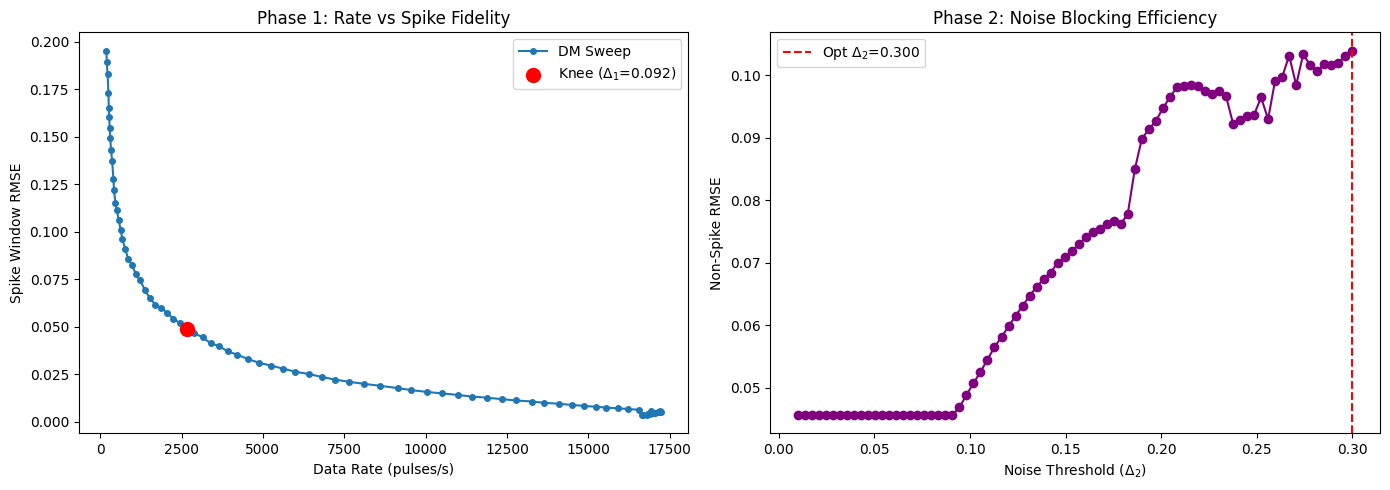

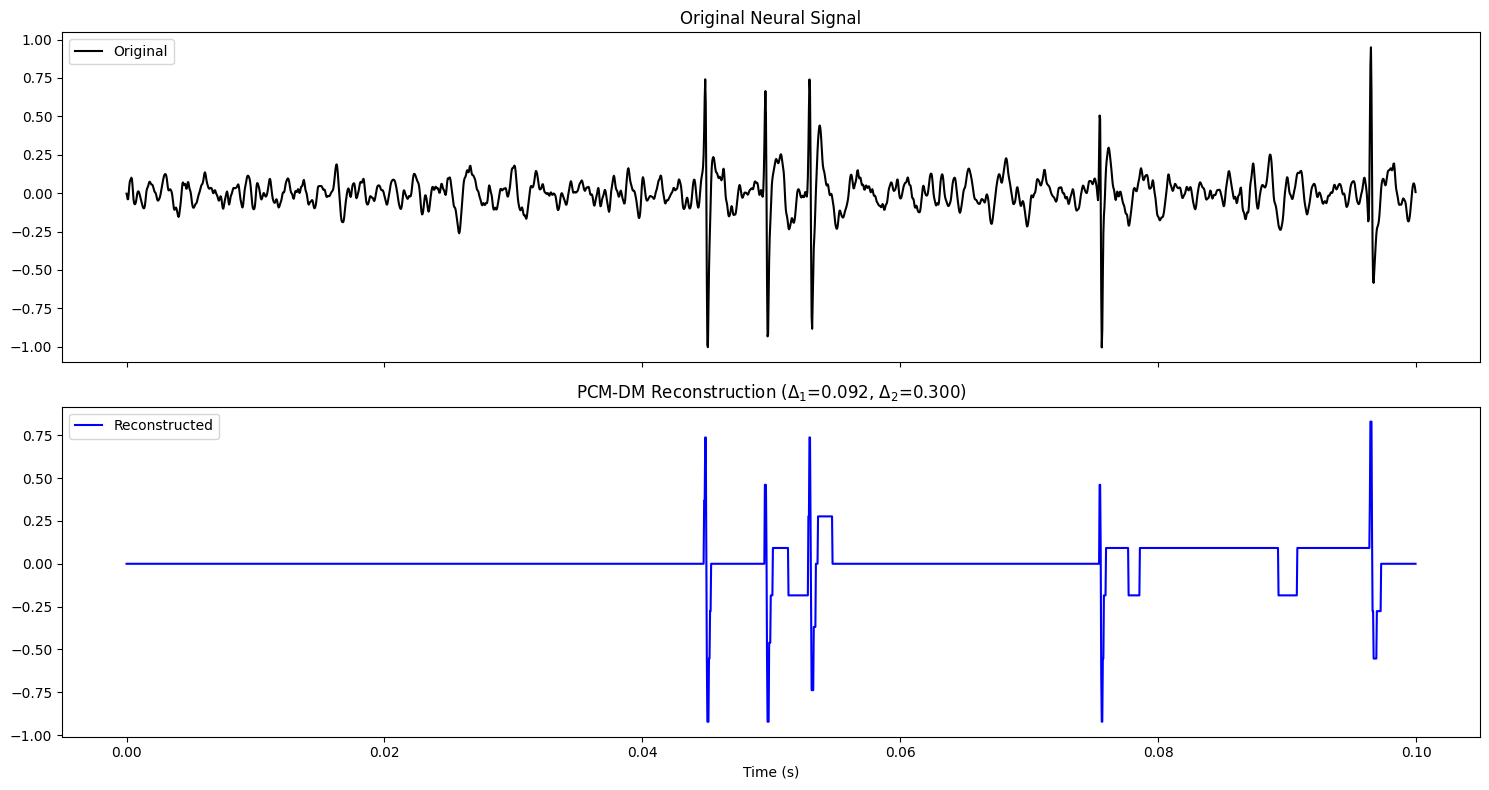

Summary:
Optimal Reconstruction Delta (d1): 0.0922
Optimal Noise Floor Delta (d2):    0.3000
Final Pulse Rate:                  376.00 pulses/s


In [ ]:
c

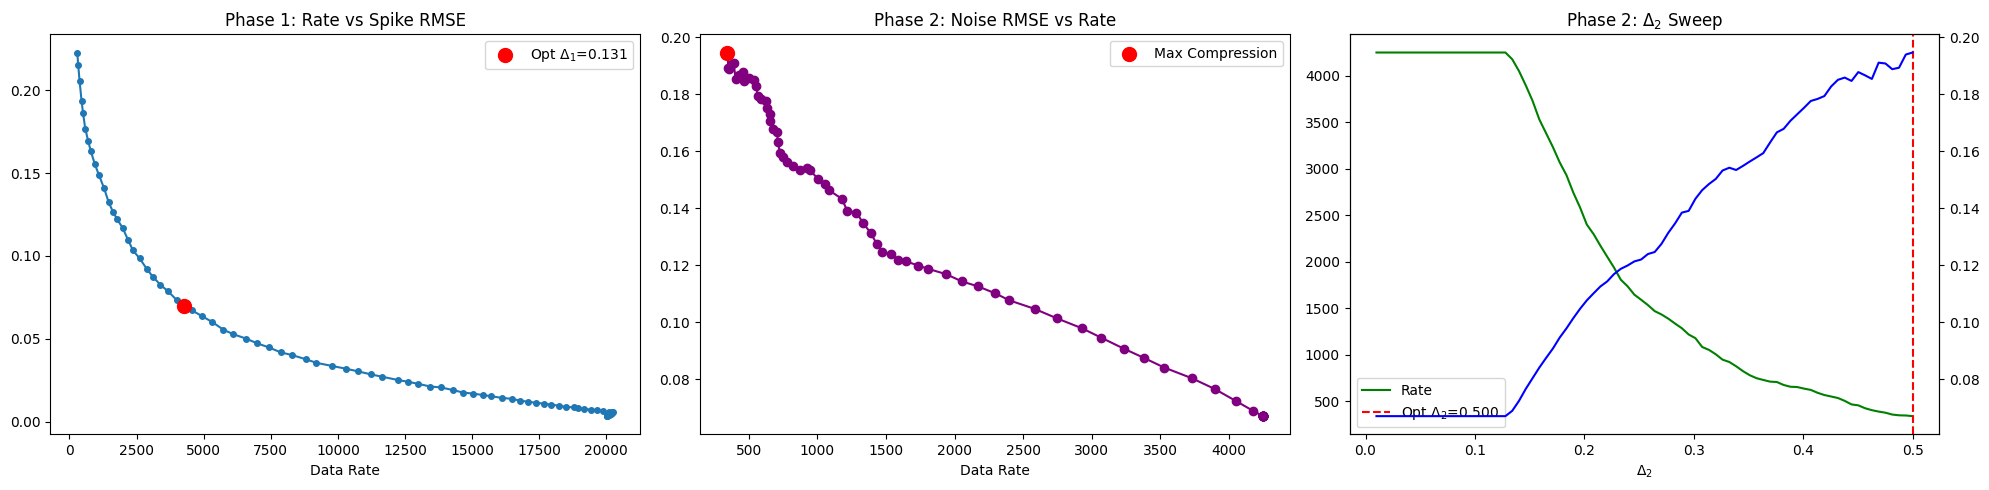

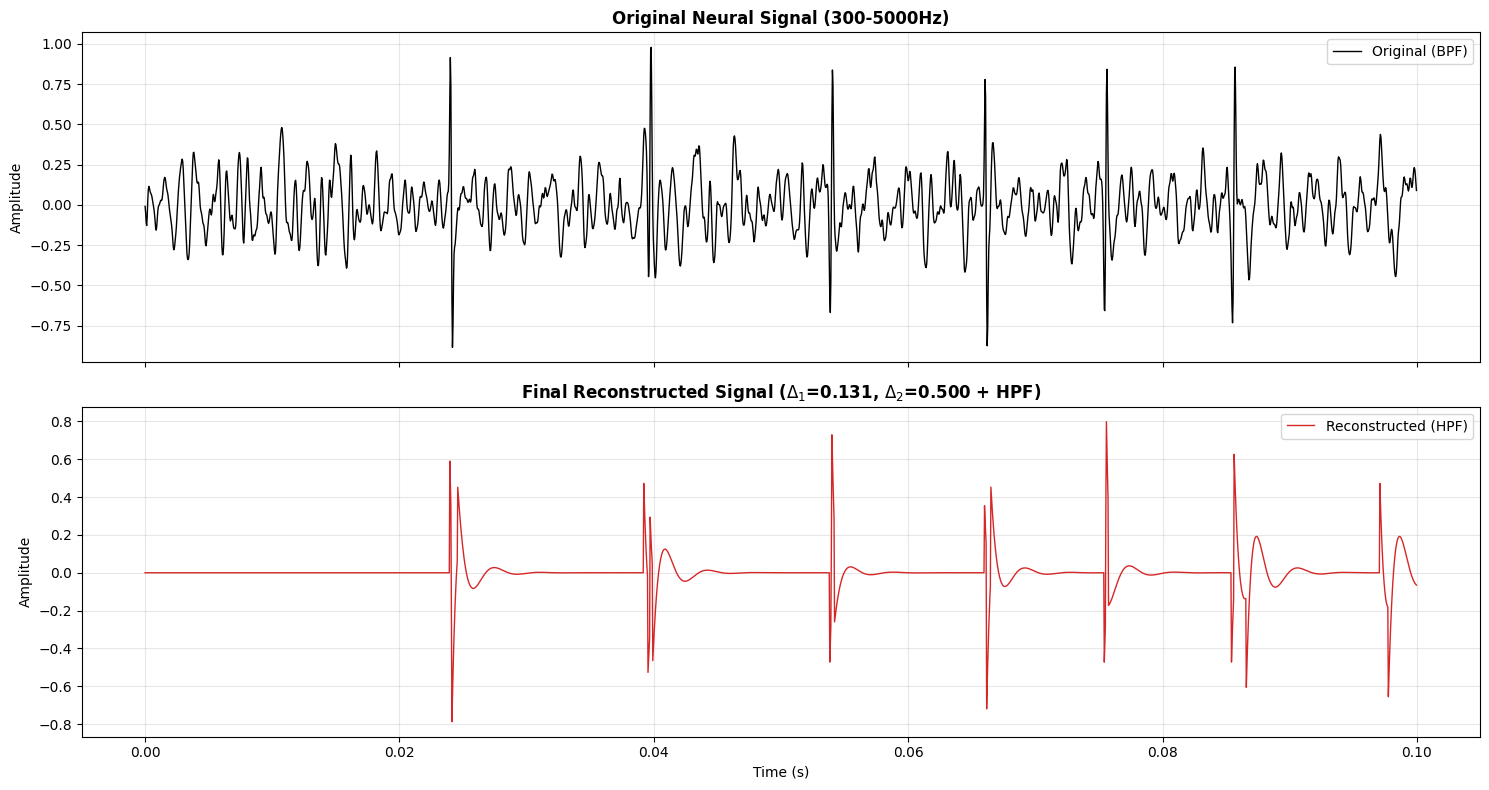


Summary Analysis:
------------------------------
Optimal Reconstruction Delta (d1): 0.1308
Optimal Noise Floor Delta (d2):    0.5000
Final Pulse Rate:                  340.00 pulses/s
Noise Region RMSE:                 0.1947


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy.io import loadmat

# ==========================================
# 1. Load Data / Synthetic Generation
# ==========================================
try:
    MAT = loadmat('./C_Easy1_noise02.mat')
    rawData = np.array(MAT['data'])[0]
    spikeTimeGT = np.array(MAT['spike_times'])[0][0][0].flatten()
    sampling_interval = np.array(MAT['samplingInterval'][0][0]) * 1e-3
    sample_rate = int(1 / sampling_interval)
    data = lfilter(*butter(4, [300*2/sample_rate, 5000*2/sample_rate], btype='band'), rawData[:int(sample_rate)])
except FileNotFoundError:
    sample_rate = 24000
    duration = 1.0
    t = np.arange(0, duration, 1/sample_rate)
    rawData = np.random.normal(0, 0.05, len(t))
    spikeTimeGT = np.sort(np.random.choice(np.arange(100, len(t)-100), 50, replace=False))
    # Synthetic spike template
    ts = np.linspace(-1, 2, 48)
    spike = -np.exp(-ts**2 / 0.1) + 0.5 * np.exp(-(ts-0.5)**2 / 0.2)
    spike = spike / np.max(np.abs(spike))
    for idx in spikeTimeGT: rawData[idx:idx+48] += spike
    data = lfilter(*butter(4, [300*2/sample_rate, 5000*2/sample_rate], btype='band'), rawData)

# ==========================================
# 2. Core Logic Functions
# ==========================================
def delta_modulation_PCM(x, on_th, off_th, noise_threshold=0.0):
    """PCM-DM with added noise blocking threshold."""
    pulseTrain = np.zeros(len(x), dtype=int)
    y_rec = np.zeros(len(x), dtype=float)
    spikes = [] 
    last = 0.0

    for i in range(len(x)):
        diff = x[i] - last
        # Noise Blocking: if diff is under threshold, stay flat
        if abs(diff) < noise_threshold:
            y_rec[i] = last
            continue

        if diff > on_th:
            k = int(np.floor(diff / on_th))
            pulseTrain[i] = k
            last += k * on_th
            spikes.append((i, k))
        elif diff < off_th:
            k = int(np.floor(diff / off_th)) 
            pulseTrain[i] = -k                    
            last += k * off_th             
            spikes.append((i, -k))
        y_rec[i] = last
    return pulseTrain, y_rec, spikes

def spk_rmse(data, reconstructed_signal, spikeTimeGT):
    data_spk, reconstructed_spk = [], []
    valid_spikes = spikeTimeGT[spikeTimeGT < (len(data) - 48)]
    for i in valid_spikes:
        idx = int(i)
        data_spk.extend(data[idx : idx + 48])
        reconstructed_spk.extend(reconstructed_signal[idx : idx + 48])
    return np.sqrt(np.mean((np.array(data_spk) - np.array(reconstructed_spk))**2)) if data_spk else 0

def non_spk_rmse(data, reconstructed_signal, spikeTimeGT):
    mask = np.ones(len(data), dtype=bool)
    for i in spikeTimeGT[spikeTimeGT < (len(data) - 48)]:
        mask[int(i) : int(i) + 48] = False
    return np.sqrt(np.mean((data[mask] - reconstructed_signal[mask])**2))

def find_knee(x, y):
    """Distance-from-line knee point detection."""
    coords = np.vstack((x, y)).T
    first_pt, last_pt = coords[0], coords[-1]
    line_vec = last_pt - first_pt
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = coords - first_pt
    scalar_prod = np.sum(vec_from_first * line_vec_norm, axis=1)
    vec_to_line = vec_from_first - np.outer(scalar_prod, line_vec_norm)
    dist_to_line = np.sqrt(np.sum(vec_to_line**2, axis=1))
    knee_idx = np.argmax(dist_to_line)
    return x.iloc[knee_idx], y.iloc[knee_idx], knee_idx

# ... [Keep sections 1 and 2 from your previous code] ...

# ==========================================
# 3. Two-Step Optimization
# ==========================================

# Phase 1: Optimize delta_1 based on DataRate vs spk_rmse
deltas = np.logspace(np.log10(0.005), np.log10(0.5), 80)
res_p1 = []
duration = len(data) / sample_rate

for d in deltas:
    pt, y, _ = delta_modulation_PCM(data, d, -d, noise_threshold=0.01)
    rmse = spk_rmse(data, y, spikeTimeGT)
    rate = np.sum(np.abs(pt) != 0) / duration
    res_p1.append({"delta": d, "spk_rmse": rmse, "DataRate": rate})

df1 = pd.DataFrame(res_p1).sort_values("DataRate")
opt_rate_p1, opt_rmse_p1, opt_idx_p1 = find_knee(df1["DataRate"], df1["spk_rmse"])
opt_delta_1 = df1.iloc[opt_idx_p1]["delta"]

# Phase 2: Optimize delta_2 (Noise Floor) based on non_spk_rmse vs Data Rate
noise_range = np.linspace(0.01, 0.5, 80)
res_p2 = []

for nf in noise_range:
    pt, y, _ = delta_modulation_PCM(data, opt_delta_1, -opt_delta_1, noise_threshold=nf)
    ns_err = non_spk_rmse(data, y, spikeTimeGT)
    rate = np.sum(np.abs(pt) != 0) / duration
    res_p2.append({"noise_delta": nf, "ns_rmse": ns_err, "DataRate": rate})

df2 = pd.DataFrame(res_p2)

# --- NEW LOGIC FOR PHASE 2 ---
# You want: Highest RMSE and Lowest Data Rate.
# Since increasing noise_delta increases RMSE and decreases Data Rate, 
# we find the row that maximizes RMSE (which will naturally have the lowest rate in this range).
best_idx_p2 = df2["ns_rmse"].idxmax()
opt_delta_2 = df2.loc[best_idx_p2]["noise_delta"]
opt_rate_p2 = df2.loc[best_idx_p2]["DataRate"]
opt_rmse_p2 = df2.loc[best_idx_p2]["ns_rmse"]


# ==========================================
# 4. Final Reconstruction and HPF Processing
# ==========================================
pt_final, y_final, spikes_final = delta_modulation_PCM(data, opt_delta_1, -opt_delta_1, noise_threshold=opt_delta_2)

# High-Pass Filter for the Reconstructed Signal
# Typically set to 300Hz to match the lower bound of the original spike bandpass
def highpass_filter(signal, cutoff=300, fs=24000):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(4, normal_cutoff, btype='high', analog=False)
    return lfilter(b, a, signal)

# Apply filter to the reconstructed output
y_filtered = highpass_filter(y_final, cutoff=300, fs=sample_rate)

time_axis = np.arange(len(data)) / sample_rate

# --- Optimization Visualization (Phase 1 & Phase 2) ---
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].plot(df1["DataRate"], df1["spk_rmse"], 'o-', markersize=4)
axs[0].scatter(opt_rate_p1, opt_rmse_p1, color='red', s=100, zorder=5, label=f'Opt $\Delta_1$={opt_delta_1:.3f}')
axs[0].set_title("Phase 1: Rate vs Spike RMSE"); axs[0].set_xlabel("Data Rate"); axs[0].legend()

axs[1].plot(df2["DataRate"], df2["ns_rmse"], 'o-', color='purple')
axs[1].scatter(opt_rate_p2, opt_rmse_p2, color='red', s=100, zorder=5, label='Max Compression')
axs[1].set_title("Phase 2: Noise RMSE vs Rate"); axs[1].set_xlabel("Data Rate"); axs[1].legend()

axs[2].plot(df2["noise_delta"], df2["DataRate"], 'g-', label='Rate')
ax2_t = axs[2].twinx()
ax2_t.plot(df2["noise_delta"], df2["ns_rmse"], 'b-', label='RMSE')
axs[2].axvline(opt_delta_2, color='red', linestyle='--', label=f'Opt $\Delta_2$={opt_delta_2:.3f}')
axs[2].set_title("Phase 2: $\Delta_2$ Sweep"); axs[2].set_xlabel("$\Delta_2$"); axs[2].legend()
plt.tight_layout(); plt.show()

# --- Reconstructed Plots (Original vs. HPF Reconstructed) ---
zoom_idx = int(0.1 * sample_rate)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(time_axis[:zoom_idx], data[:zoom_idx], 'k', linewidth=1, label="Original (BPF)")
ax1.set_title("Original Neural Signal (300-5000Hz)", fontweight='bold')
ax1.set_ylabel("Amplitude"); ax1.legend(loc='upper right'); ax1.grid(True, alpha=0.3)

ax2.plot(time_axis[:zoom_idx], y_filtered[:zoom_idx], 'tab:red', linewidth=1, label="Reconstructed (HPF)")
ax2.set_title(f"Final Reconstructed Signal ($\Delta_1$={opt_delta_1:.3f}, $\Delta_2$={opt_delta_2:.3f} + HPF)", fontweight='bold')
ax2.set_ylabel("Amplitude"); ax2.set_xlabel("Time (s)"); ax2.legend(loc='upper right'); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ==========================================
# 5. Final Analysis
# ==========================================
print(f"\nSummary Analysis:")
print(f"{'-'*30}")
print(f"Optimal Reconstruction Delta (d1): {opt_delta_1:.4f}")
print(f"Optimal Noise Floor Delta (d2):    {opt_delta_2:.4f}")
print(f"Final Pulse Rate:                  {len(spikes_final)/duration:.2f} pulses/s")
print(f"Noise Region RMSE:                 {opt_rmse_p2:.4f}")


=== Noise threshold Δ2 = 0.10 ===
Processing group: Noise 0.05
Processing group: Noise 0.1
Processing group: Noise 0.15
Processing group: Noise 0.2


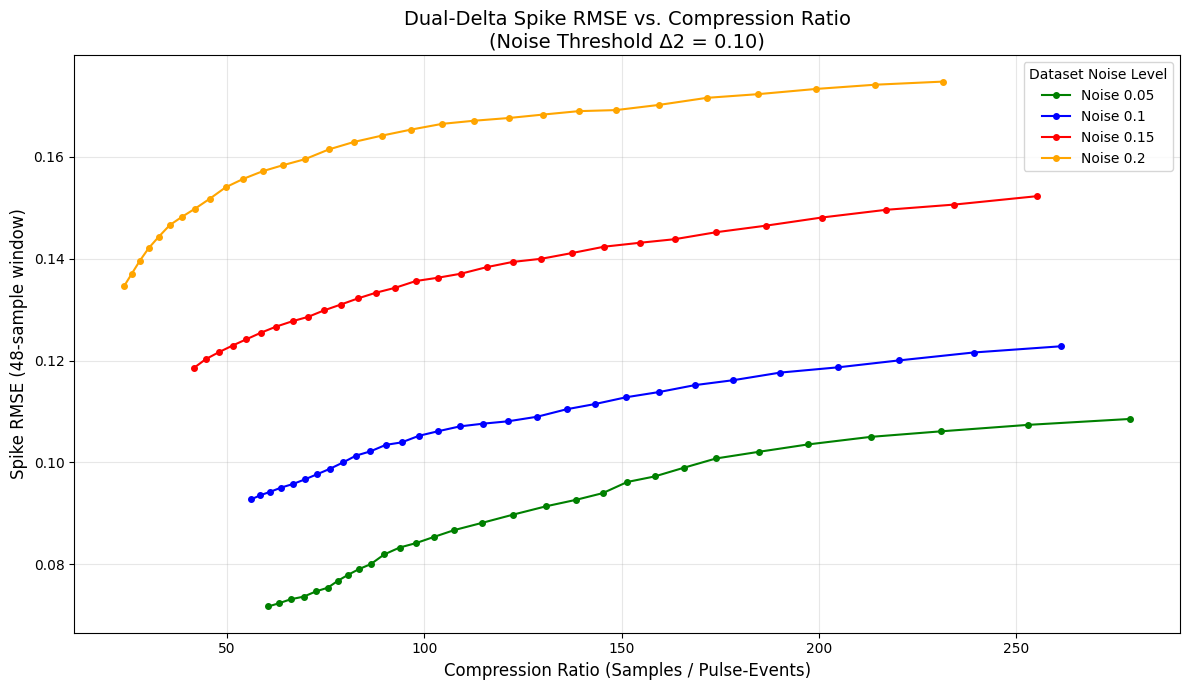


=== Noise threshold Δ2 = 0.20 ===
Processing group: Noise 0.05
Processing group: Noise 0.1
Processing group: Noise 0.15
Processing group: Noise 0.2


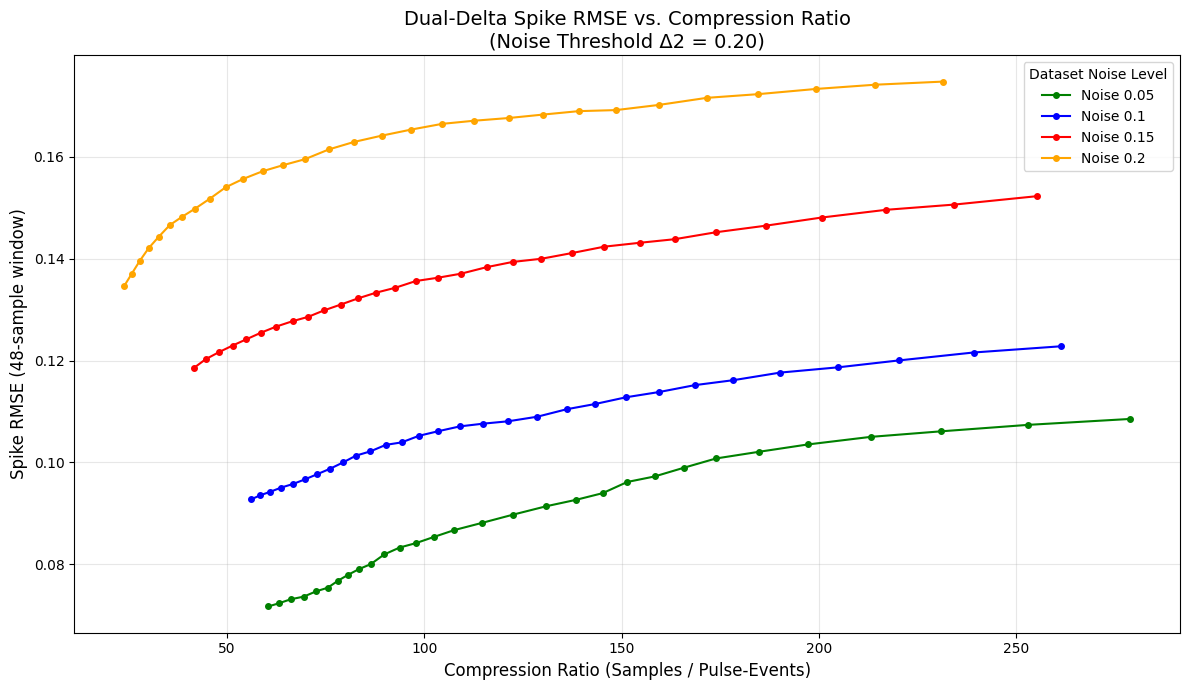


=== Noise threshold Δ2 = 0.30 ===
Processing group: Noise 0.05
Processing group: Noise 0.1
Processing group: Noise 0.15
Processing group: Noise 0.2


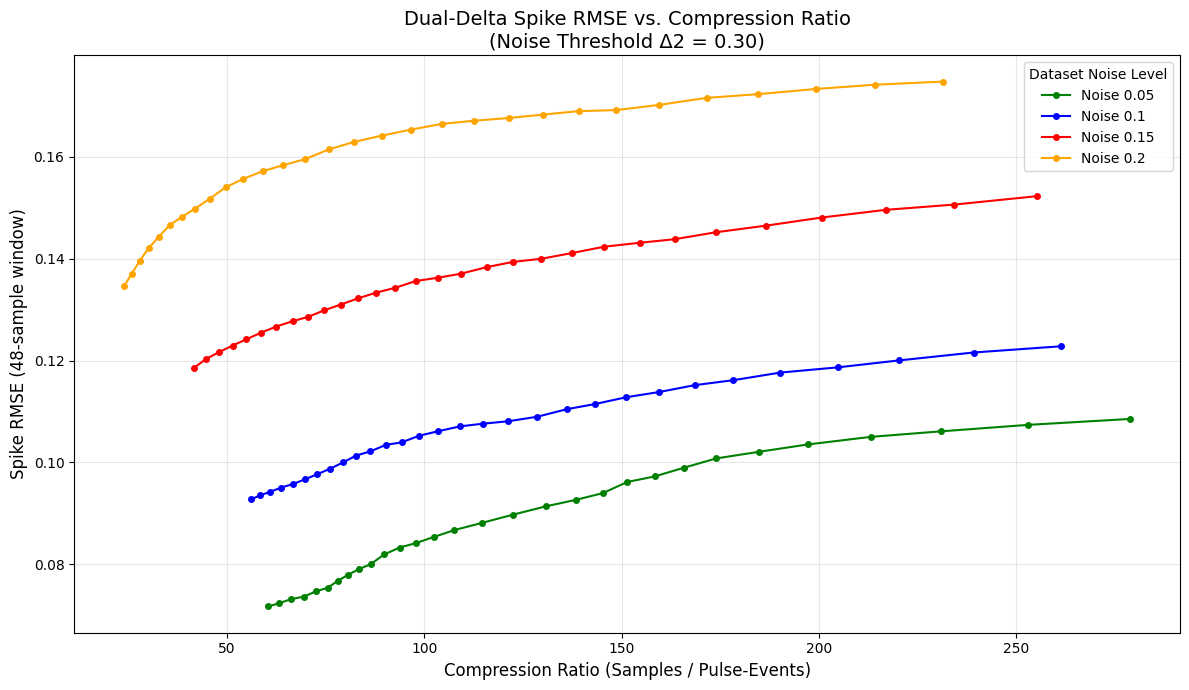


=== Noise threshold Δ2 = 0.40 ===
Processing group: Noise 0.05
Processing group: Noise 0.1
Processing group: Noise 0.15
Processing group: Noise 0.2


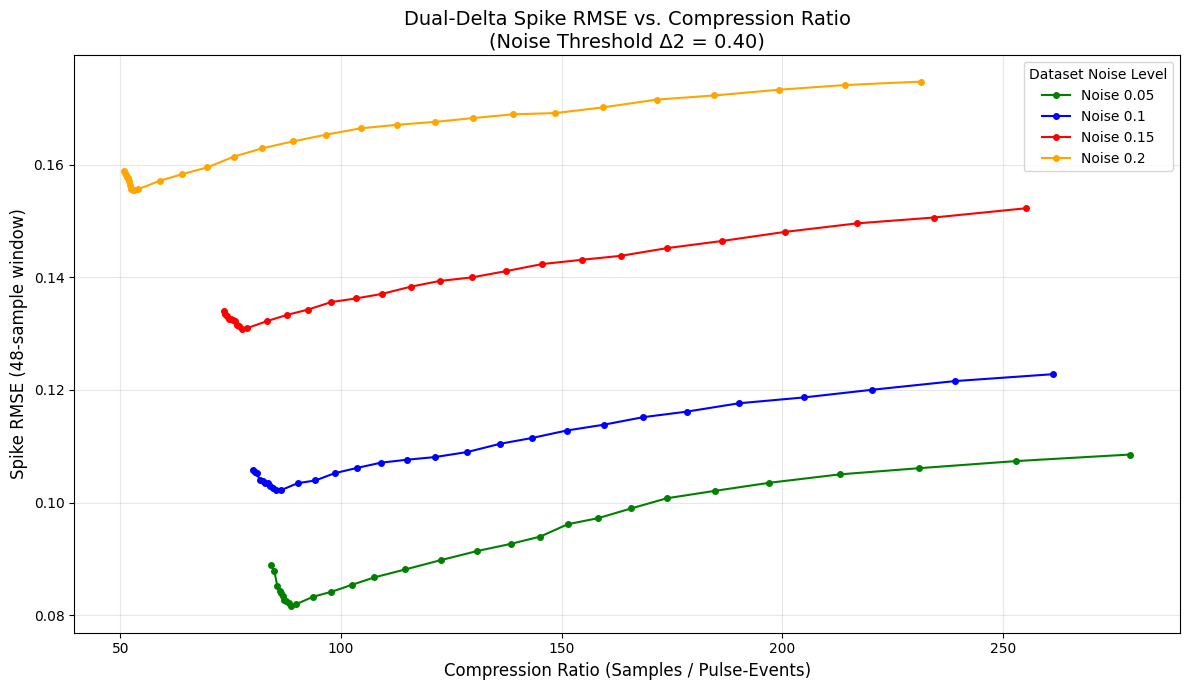


=== Noise threshold Δ2 = 0.50 ===
Processing group: Noise 0.05
Processing group: Noise 0.1
Processing group: Noise 0.15
Processing group: Noise 0.2


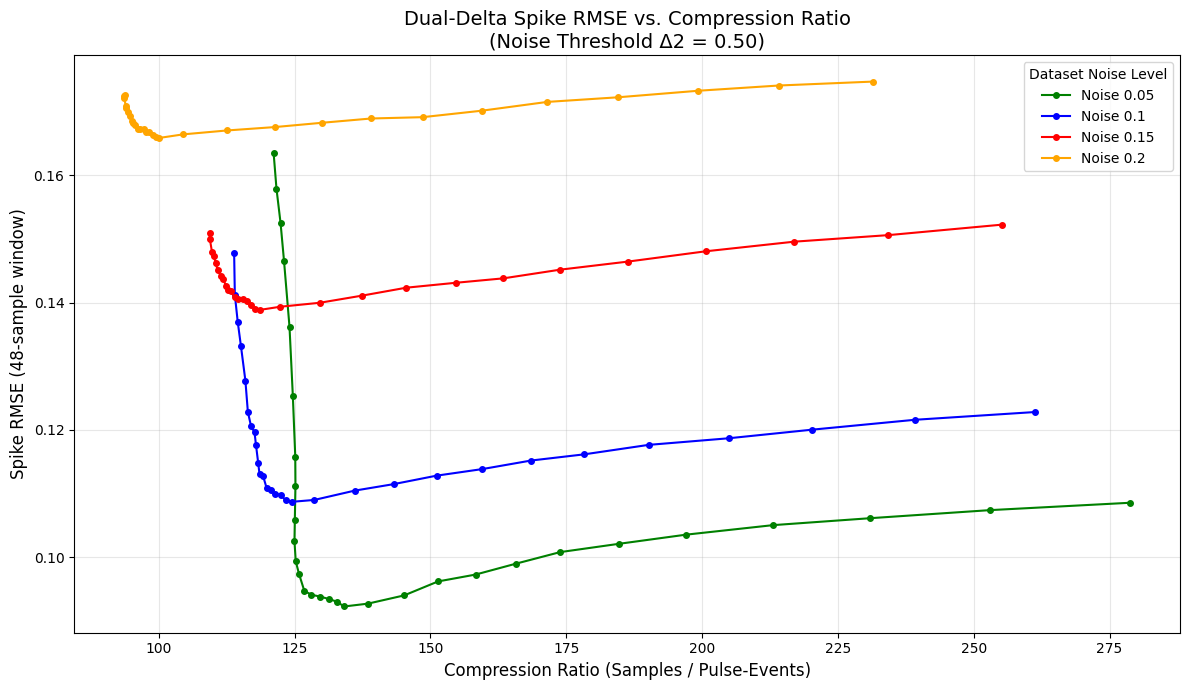

In [ ]:
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter


def delta_modulation_PCM_dual(x, on_th, off_th, noise_threshold=0.0):
    pulseTrain = np.zeros(len(x), dtype=int)
    y_rec = np.zeros(len(x), dtype=float)
    last = 0.0
    for i in range(len(x)):
        diff = x[i] - last
        if abs(diff) < noise_threshold:
            y_rec[i] = last
            continue
        if diff > on_th:
            k = int(np.floor(diff / on_th))
            pulseTrain[i] = k
            last += k * on_th
        elif diff < off_th:
            k = int(np.floor(diff / off_th)) 
            pulseTrain[i] = -k
            last += k * off_th
        y_rec[i] = last
    return pulseTrain, y_rec


def spk_rmse(data, reconstructed_signal, spikeTimeGT):
    data_spk, reconstructed_spk = [], []
    valid_spikes = spikeTimeGT[(spikeTimeGT >= 0) & (spikeTimeGT < (len(data) - 48))]
    for i in valid_spikes:
        idx = int(i)
        data_spk.extend(data[idx : idx + 48])
        reconstructed_spk.extend(reconstructed_signal[idx : idx + 48])
    return np.sqrt(np.mean((np.array(data_spk) - np.array(reconstructed_spk))**2)) if data_spk else 0


noise_sets = {
    "Noise 0.05": ["C_Easy1_noise005.mat", "C_Easy2_noise005.mat", "C_Difficult1_noise005.mat", "C_Difficult2_noise005.mat"],
    "Noise 0.1":  ["C_Easy1_noise01.mat", "C_Easy2_noise01.mat", "C_Difficult1_noise01.mat", "C_Difficult2_noise01.mat"],
    "Noise 0.15": ["C_Easy1_noise015.mat", "C_Easy2_noise015.mat", "C_Difficult1_noise015.mat", "C_Difficult2_noise015.mat"],
    "Noise 0.2":  ["C_Easy1_noise02.mat", "C_Easy2_noise02.mat", "C_Difficult1_noise02.mat", "C_Difficult2_noise02.mat"]
}

sample_rate = 24000
deltas = np.logspace(np.log10(0.3), np.log10(0.7), 30)
colors = {"Noise 0.05": "green", "Noise 0.1": "blue",
          "Noise 0.15": "red", "Noise 0.2": "orange"}

# Sweep opt_delta_2 from 0.1 to 0.5, step 0.05
opt_delta_2_values = np.arange(0.1, 0.5 + 1e-9, 0.1)

for opt_delta_2 in opt_delta_2_values:
    plt.figure(figsize=(12, 7))
    print(f"\n=== Noise threshold Δ2 = {opt_delta_2:.2f} ===")

    for label, files in noise_sets.items():
        all_file_rmse = []
        all_file_cr = []

        print(f"Processing group: {label}")
        for filename in files:
            try:
                mat = sio.loadmat(filename)
                raw_sig = mat['data'].flatten()

                st_cell = mat['spike_times']
                spike_indices = []
                for i in range(st_cell.shape[1]):
                    times_ms = st_cell[0, i].flatten()
                    indices = np.round((times_ms / 1000.0) * sample_rate).astype(int)
                    spike_indices.extend(indices)
                spike_indices = np.sort(np.unique(spike_indices))

                b, a = butter(4, [300 * 2 / sample_rate, 5000 * 2 / sample_rate], btype='band')
                data = lfilter(b, a, raw_sig)

                file_rmse, file_cr = [], []
                for d in deltas:
                    pt, y_rec = delta_modulation_PCM_dual(
                        data, d, -d, noise_threshold=opt_delta_2
                    )

                    rmse_val = spk_rmse(data, y_rec, spike_indices)
                    total_events = np.sum(np.abs(pt) != 0)
                    cr_val = len(data) / total_events if total_events > 0 else np.nan

                    file_rmse.append(rmse_val)
                    file_cr.append(cr_val)

                all_file_rmse.append(file_rmse)
                all_file_cr.append(file_cr)

            except FileNotFoundError:
                continue

        if all_file_rmse:
            avg_rmse = np.nanmean(all_file_rmse, axis=0)
            avg_cr = np.nanmean(all_file_cr, axis=0)
            plt.plot(avg_cr, avg_rmse, '-o', markersize=4,
                     label=label, color=colors[label])

    plt.title(f"Dual-Delta Spike RMSE vs. Compression Ratio\n"
              f"(Noise Threshold Δ2 = {opt_delta_2:.2f})", fontsize=14)
    plt.xlabel("Compression Ratio (Samples / Pulse-Events)", fontsize=12)
    plt.ylabel("Spike RMSE (48-sample window)", fontsize=12)
    plt.grid(True, which='both', alpha=0.3)
    plt.legend(title="Dataset Noise Level")
    plt.tight_layout()
    plt.show()
